In [1]:
from src.dataset import load_dataset
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target,fit_rank_pdfs_loglik, plot_ranked_pdfs
from regression.PolynomialRegressor.polynomial_regression import PolynomialRegression
import matplotlib.pyplot as plt
from dataset import save_processed_dataset
import os
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from regression.probabilistic_rf_scoring import get_regression_score
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

ModuleNotFoundError: No module named 'src'

In [ ]:
TRAIN_PATH_FULL="../../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/polynomial_regression/model_target/"
MODEL_PATH="polynomial_regression_model_target.pkl"
RESIDUI_CSV="residui.csv"
ITERATIONS = 1000
TARGET_COL = "trq_target"
FEUTURE=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
DEGREE = (1,2,3)

In [ ]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)


X_train = train_df[FEUTURE].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEUTURE].values
y_test = test_df[TARGET_COL].values


Degree  1
MAE: 0.1849696331955001
MSE: 0.0653116873993568
RMSE: 0.2555615139244499
R²: 0.9996772304016452


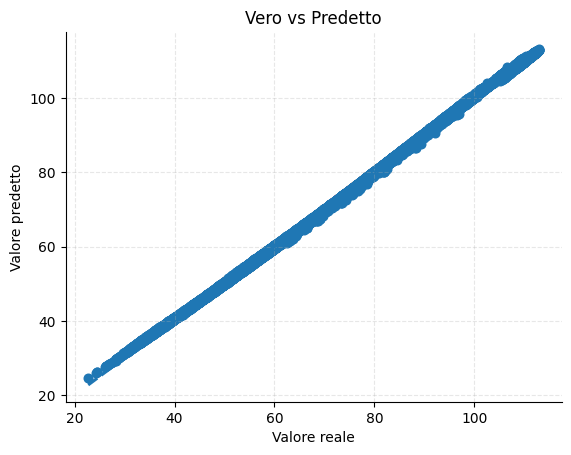


Degree  2
MAE: 0.021049430276294308
MSE: 0.001331155387866703
RMSE: 0.036485002231967906
R²: 0.9999934214455789


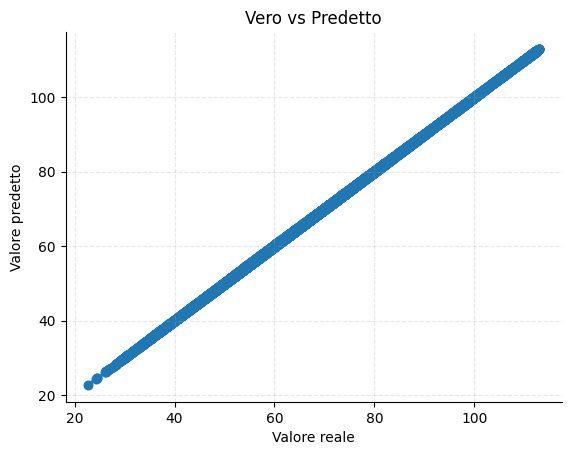


Degree  3
MAE: 0.017072748387306772
MSE: 0.0008022632573286177
RMSE: 0.028324252105371074
R²: 0.9999960352243273


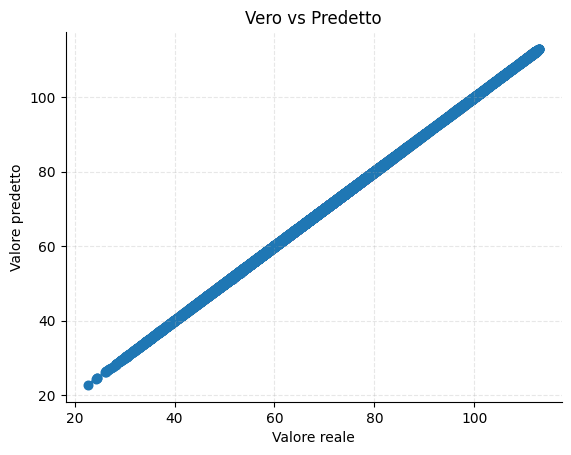

In [ ]:
for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [ ]:
train_full=load_dataset(TRAIN_PATH_FULL)
X_train_full = train_full[FEUTURE].values
y_train_full = train_full[TARGET_COL].values

In [ ]:
model = PolynomialRegression(degree=2)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  os.makedirs(OUTPUT_PATH, exist_ok=True)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [ ]:
if os.path.exists( not OUTPUT_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=OUTPUT_PATH)

In [ ]:
residui = load_dataset(OUTPUT_PATH + RESIDUI_CSV)

test_row = test_df.iloc[24]
test_x = test_row[FEUTURE].to_frame().T
test_y_true =(test_row["trq_measured"] / test_row["trq_target"] - 1) * 100
target_pred = model.predict(test_x)[0]
trq_margin_pred = (test_row["trq_measured"]/ target_pred - 1) * 100

rows = []
for m in range(ITERATIONS):
    residual = float(residui.sample(n=1)["residual"].iloc[0])
    rows.append({"trq_target_probability": target_pred + residual})

distribution = pd.DataFrame(rows)
distribution["trq_margin"] = (test_row["trq_measured"] / distribution["trq_target_probability"] - 1) * 100
distribution.head()

,trq_target_probability,trq_margin
0,70.827782,6.737777
1,70.771150,6.823189
2,70.812234,6.761213
3,70.815733,6.755938
4,70.797406,6.783573


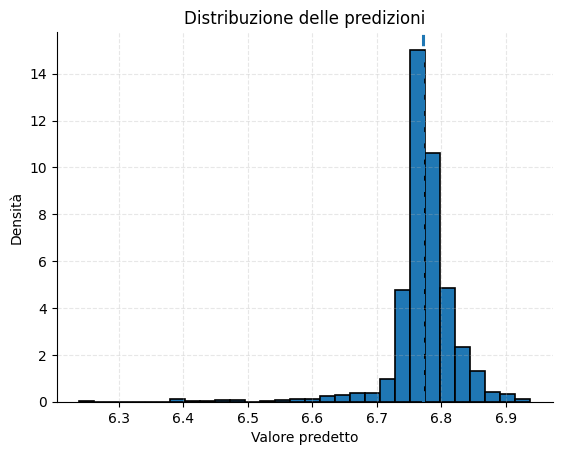

In [ ]:
plt.figure()
plt.hist(distribution["trq_margin"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [ ]:
print(distribution["trq_margin"])
ranking,best= fit_rank_pdfs_loglik(distribution["trq_margin"])

0      6.737777
1      6.823189
2      6.761213
3      6.755938
4      6.783573
         ...   
995    6.693127
996    6.765516
997    6.781744
998    6.738209
999    6.796304
Name: trq_margin, Length: 1000, dtype: float64

=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=1800.09
02) cauchy       | loglik=1758.50
03) laplace      | loglik=1743.69
04) logistic     | loglik=1673.19
05) weibull_min  | loglik=1571.77
06) norm         | loglik=1453.57
07) lognorm      | loglik=1453.56
08) f            | loglik=1452.94
09) nakagami     | loglik=1452.91
10) chi2         | loglik=1392.36
11) powerlaw     | loglik=906.66
12) gumbel_r     | loglik=886.27
13) uniform      | loglik=358.49
14) erlang       | loglik=299.89
15) rayleigh     | loglik=297.74
16) betaprime    | loglik=-19.89
17) expon        | loglik=-370.37
18) pareto       | loglik=-370.37
19) gamma        | loglik=-638.48
20) beta         | loglik=-27631.02


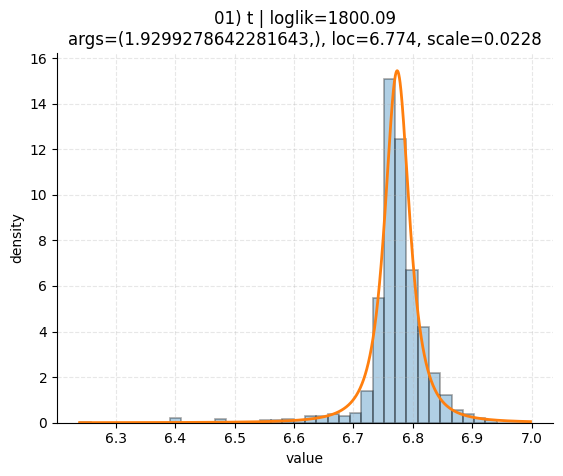

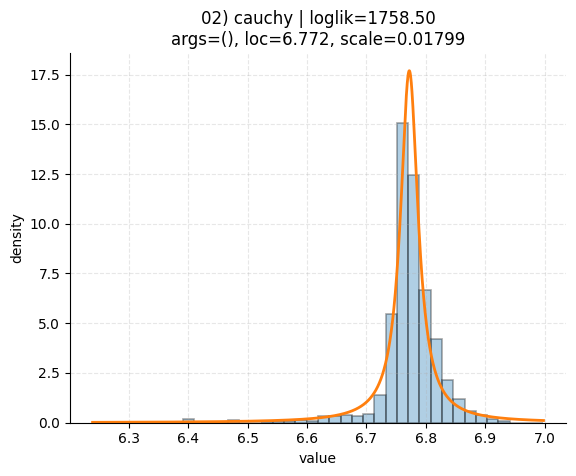

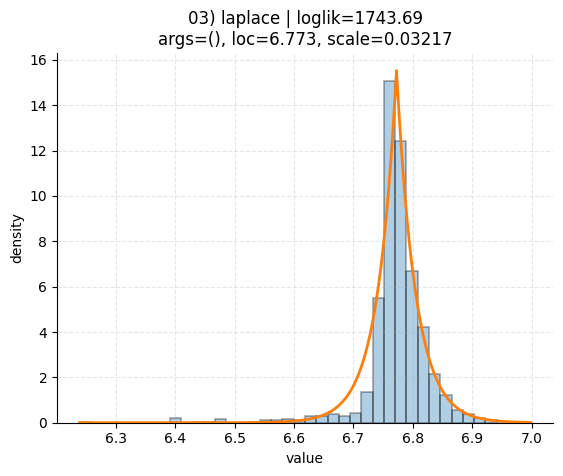

In [ ]:
plot_ranked_pdfs(ranking,distribution["trq_margin"])

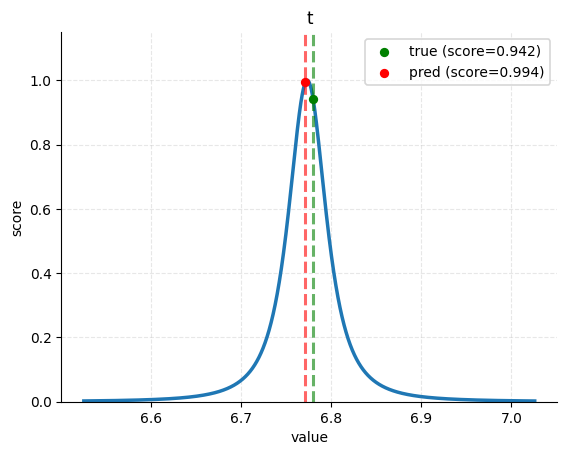

{'pdf_type': 't',
 'true_target': 6.780159035560662,
 'prediction': 6.771588829704145,
 'score_true': 0.941778908873516,
 'score_pred': 0.9942996842727803,
 'x_range': (6.525873932632404, 7.025873932632404)}

In [ ]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],test_y_true,trq_margin_pred)